In [1]:
#connecting Database to Notebook
import sqlite3, pandas as pd
conn=sqlite3.connect(r"C:\Users\Sirlaw\Desktop\SQL Analysis\Orders.db.txt")


In [2]:
# Revenue and Average order value by Product
query = """
SELECT Product,
    SUM(Quantity * UnitPrice) AS Revenue,
    AVG(Quantity * UnitPrice) AS AvgOrderValue
FROM Orders
GROUP BY Product
ORDER BY Revenue DESC
"""
df = pd.read_sql_query(query, conn)
df

,Product,Revenue,AvgOrderValue
0,Chair,195620.11,1098.989382
1,Printer,195612.61,1080.732652
2,Laptop,192126.56,1110.558150
3,Tablet,186568.95,1042.284637
4,Monitor,175651.41,1077.616012
5,Desk,167459.93,985.058412
6,Phone,151722.39,972.579423


In [3]:
#  Payment Method with the Highest Revenue
query_payment = """
SELECT PaymentMethod,
    SUM(Quantity * UnitPrice) AS Revenue,
    COUNT(*) AS OrderCount,
    AVG(Quantity * UnitPrice) AS AvgOrderValue
FROM Orders
GROUP BY PaymentMethod
ORDER BY Revenue DESC;
"""
df_payment = pd.read_sql_query(query_payment, conn)
df_payment

,PaymentMethod,Revenue,OrderCount,AvgOrderValue
0,Credit Card,263847.63,234,1127.553974
1,Online,262442.94,258,1017.220698
2,Cash,259786.29,246,1056.041829
3,Gift Card,246323.92,230,1070.973565
4,Debit Card,232361.18,232,1001.556810


In [4]:
# Top 10 Customers by Spend
cols = pd.read_sql_query("PRAGMA table_info('Orders')", conn)['name'].tolist()
candidates = ['Customer', 'CustomerID', 'CustomerName', 'Client', 'ClientID', 'Buyer', 'BuyerID', 'Account']
customer_col = next((c for c in candidates if c in cols), None)

if customer_col is None:
    raise ValueError(f"No customer-like column found in Orders table. Available columns: {cols}")

query_top_customers = f"""
SELECT {customer_col} AS Customer,
       SUM(Quantity * UnitPrice) AS TotalSpend,
       COUNT(*) AS OrderCount,
       AVG(Quantity * UnitPrice) AS AvgOrderValue
FROM Orders
GROUP BY {customer_col}
ORDER BY TotalSpend DESC
LIMIT 10
"""
df_top_customers = pd.read_sql_query(query_top_customers, conn)
df_top_customers

,Customer,TotalSpend,OrderCount,AvgOrderValue
0,C38840,5723.23,2,2861.615
1,C57276,3456.40,1,3456.400
2,C67260,3390.80,1,3390.800
3,C13877,3384.90,1,3384.900
4,C18404,3370.20,1,3370.200
5,C16775,3353.75,1,3353.750
6,C65986,3352.40,1,3352.400
7,C47778,3334.00,1,3334.000
8,C59183,3322.55,1,3322.550
9,C25276,3313.90,1,3313.900


,Revenue,OrderCount,AvgOrderValue
YearMonth,,,
2023-01-01,56685.75,47,1206.079787
2023-02-01,40117.66,37,1084.261081
2023-03-01,48609.37,43,1130.450465
2023-04-01,27751.71,31,895.216452
2023-05-01,63836.84,49,1302.792653
2023-06-01,49500.19,45,1100.004222
2023-07-01,42820.66,44,973.196818
2023-08-01,54352.14,51,1065.728235
2023-09-01,29526.67,29,1018.161034


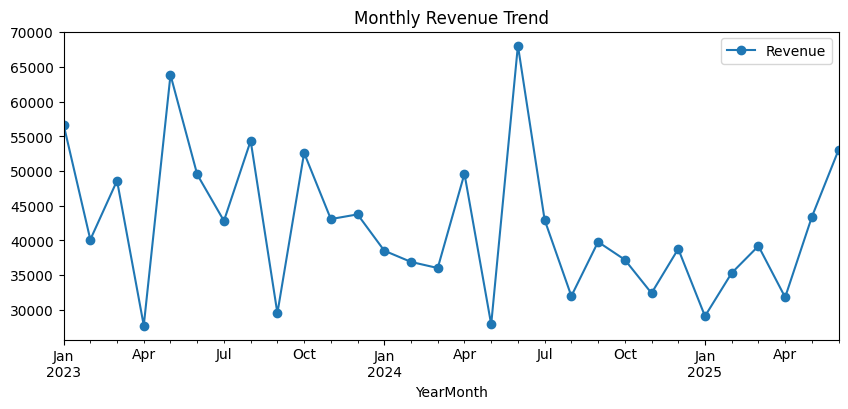

In [5]:
# Monthly Revenue trend
query_monthly = """
SELECT strftime('%Y-%m', Date) AS YearMonth,
    SUM(Quantity * UnitPrice) AS Revenue,
    COUNT(*) AS OrderCount,
    AVG(Quantity * UnitPrice) AS AvgOrderValue
FROM Orders
GROUP BY YearMonth
ORDER BY YearMonth;
"""
df_monthly = pd.read_sql_query(query_monthly, conn)
df_monthly['YearMonth'] = pd.to_datetime(df_monthly['YearMonth'], format='%Y-%m')
df_monthly = df_monthly.sort_values('YearMonth').set_index('YearMonth')
df_monthly['Revenue'] = df_monthly['Revenue'].astype(float)
df_monthly.plot(y='Revenue', figsize=(10,4), title='Monthly Revenue Trend', marker='o')
df_monthly

In [6]:
# Coupon Impact on AVG Order Value
query_coupon = """
SELECT
    CASE
        WHEN CouponCode IS NULL OR TRIM(CouponCode) = '' THEN 'No Coupon'
        ELSE 'Coupon Used'
    END AS CouponStatus,
    COUNT(*) AS OrderCount,
    SUM(Quantity * UnitPrice) AS Revenue,
    AVG(Quantity * UnitPrice) AS AvgOrderValue
FROM Orders
GROUP BY CouponStatus
ORDER BY CouponStatus;
"""
df_coupon = pd.read_sql_query(query_coupon, conn)
df_coupon

,CouponStatus,OrderCount,Revenue,AvgOrderValue
0,Coupon Used,891,942360.55,1057.643715
1,No Coupon,309,322401.41,1043.370259


<Axes: title={'center': 'Revenue by Referral Source'}, xlabel='ReferralSource'>

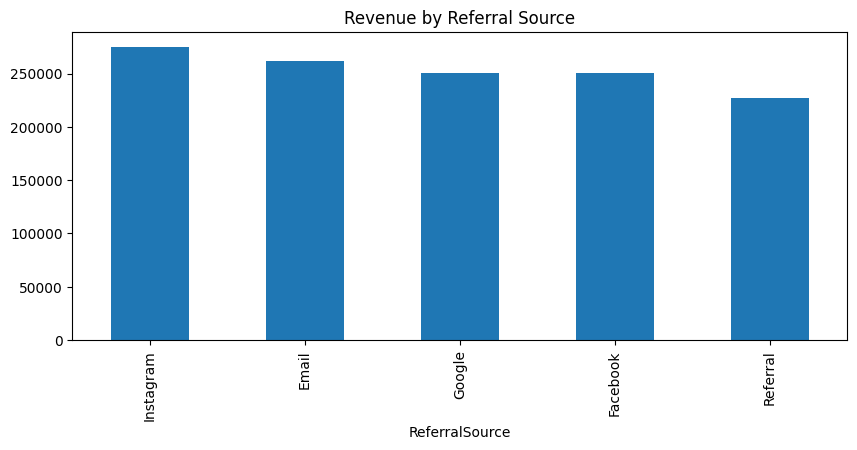

In [7]:
# Referral Source Performance
query_referral = """
SELECT
    COALESCE(NULLIF(TRIM(ReferralSource), ''), 'Unknown') AS ReferralSource,
    COUNT(*) AS OrderCount,
    SUM(Quantity * UnitPrice) AS Revenue,
    AVG(Quantity * UnitPrice) AS AvgOrderValue
FROM Orders
GROUP BY ReferralSource
ORDER BY Revenue DESC;
"""
df_referral = pd.read_sql_query(query_referral, conn)
df_referral['Revenue'] = df_referral['Revenue'].astype(float)
df_referral['RevenueShare'] = df_referral['Revenue'] / df_referral['Revenue'].sum()
df_referral
# Plot revenue by referral source
df_referral.set_index('ReferralSource')['Revenue'].plot(kind='bar', figsize=(10,4), title='Revenue by Referral Source')

In [8]:
# High Value Products
query_high_value_products = """
SELECT Product,
    SUM(Quantity * UnitPrice) AS Revenue,
    COUNT(*) AS OrderCount,
    AVG(Quantity * UnitPrice) AS AvgOrderValue
FROM Orders
GROUP BY Product
HAVING SUM(Quantity * UnitPrice) > 50000
ORDER BY Revenue DESC
"""
df_high_value_products = pd.read_sql_query(query_high_value_products, conn)
df_high_value_products

,Product,Revenue,OrderCount,AvgOrderValue
0,Chair,195620.11,178,1098.989382
1,Printer,195612.61,181,1080.732652
2,Laptop,192126.56,173,1110.558150
3,Tablet,186568.95,179,1042.284637
4,Monitor,175651.41,163,1077.616012
5,Desk,167459.93,170,985.058412
6,Phone,151722.39,156,972.579423


In [9]:
#Cancelled/Returned Orders Details
query_cancelled = f"""
SELECT OrderID,
    Date,
    {customer_col} AS Customer,
    Product,
    Quantity,
    UnitPrice,
    (Quantity * UnitPrice) AS TotalPrice,
    OrderStatus
FROM Orders
WHERE OrderStatus IN ('Cancelled', 'Returned')
ORDER BY Date DESC
"""
df_cancelled = pd.read_sql_query(query_cancelled, conn)
df_cancelled['Date'] = pd.to_datetime(df_cancelled['Date'])
df_cancelled

,OrderID,Date,Customer,Product,Quantity,UnitPrice,TotalPrice,OrderStatus
0,ORD200256,2025-06-30,C94323,Chair,5,75.81,379.05,Returned
1,ORD201107,2025-06-30,C25110,Tablet,2,63.21,126.42,Cancelled
2,ORD200773,2025-06-28,C99205,Phone,2,512.33,1024.66,Cancelled
3,ORD201039,2025-06-28,C49137,Desk,2,299.23,598.46,Cancelled
4,ORD200064,2025-06-25,C49720,Printer,3,130.61,391.83,Cancelled
...,...,...,...,...,...,...,...,...
492,ORD200262,2023-01-10,C69476,Phone,4,249.07,996.28,Returned
493,ORD201179,2023-01-08,C84630,Laptop,5,518.55,2592.75,Cancelled
494,ORD200472,2023-01-06,C60029,Chair,3,508.12,1524.36,Cancelled
495,ORD200645,2023-01-02,C82990,Laptop,2,150.05,300.10,Cancelled


In [10]:
# Returning customer metrics: count, revenue share, and avg order value comparison
query_retention = f"""
WITH cust AS (
    SELECT {customer_col} AS Customer,
                 COUNT(*) AS Orders,
                 SUM(Quantity * UnitPrice) AS Spend,
                 AVG(Quantity * UnitPrice) AS AvgOrderValue
    FROM Orders
    GROUP BY {customer_col}
)
SELECT
    (SELECT COUNT(*) FROM cust) AS TotalCustomers,
    (SELECT COUNT(*) FROM cust WHERE Orders > 1) AS ReturningCustomers,
    ROUND(1.0 * (SELECT COUNT(*) FROM cust WHERE Orders > 1) / (SELECT COUNT(*) FROM cust), 4) AS ReturningRate,
    (SELECT ROUND(SUM(Spend), 2) FROM cust WHERE Orders > 1) AS RevenueReturning,
    (SELECT ROUND(SUM(Spend), 2) FROM cust) AS TotalRevenue,
    ROUND(1.0 * (SELECT SUM(Spend) FROM cust WHERE Orders > 1) / (SELECT SUM(Spend) FROM cust), 4) AS RevenueShareReturning,
    ROUND((SELECT AVG(AvgOrderValue) FROM cust WHERE Orders > 1), 2) AS AvgOrderValue_Returning,
    ROUND((SELECT AVG(AvgOrderValue) FROM cust WHERE Orders = 1), 2) AS AvgOrderValue_OneTime
;
"""
df_retention = pd.read_sql_query(query_retention, conn)
df_retention

,TotalCustomers,ReturningCustomers,ReturningRate,RevenueReturning,TotalRevenue,RevenueShareReturning,AvgOrderValue_Returning,AvgOrderValue_OneTime
0,1189,11,0.0093,19535.78,1264761.96,0.0154,887.99,1057.07


In [ ]:
Generate a README.md file using the above SQL,python Analysis. stating the project overview,author,objectives,key findings,tools and technologies,recommendations,best questions answered. e.t.c. make it professionally attractive for Github


In [ ]:
- **E-commerce Sales Analytics with Python and SQL**: Built a data analysis workflow using SQLite and pandas to query an orders database, calculate product revenue, average order value, payment method performance, coupon impact, and monthly revenue trends. Ideal for GitHub as a reproducible analytics project showcasing SQL extraction and Python visualization.

- **Customer and Retention Insights Dashboard**: Developed SQL-driven customer segmentation and retention analysis with pandas, identifying top customers, returning customer revenue share, canceled/returned order details, and referral source performance. This project highlights end-to-end data exploration and business-focused insights for a GitHub portfolio.